In [1]:
include("../RayTracing.jl")

Main.RayTracing

In [2]:
LL = 1.0
texmap = RayTracing.jmfp("/Users/johnmyslinski/Documents/PBRJ/ref/smile3.png")

"/Users/johnmyslinski/Documents/PBRJ/ref/smile3.png"

In [ ]:
function convert_png_to_exr(input_path::String, output_path::String, replacement_color=(0.3, 0.3, 1.3))
    # Read the PNG file
    println("Reading PNG file: $input_path")
    img = RayTracing.load(input_path)
    
    # Get dimensions
    height, width = size(img)
    println("Image dimensions: $(width)×$(height)")
    
    # Create new image for EXR
    # EXR works with floating-point values, so we'll use RGB{Float32}
    new_img = similar(img, RayTracing.RGB{Float32})
    
    # Create the replacement color as RGB{Float32}
    r, g, b = replacement_color
    replacement = RayTracing.RGB{Float32}(r, g, b)
    
    # Process each pixel
    black = RayTracing.RGB{Float32}(0.0, 0.0, 0.0)
    
    println("Processing pixels...")
    for i in RayTracing.CartesianIndices(img)
        pixel = RayTracing.RGB{Float32}(convert(RayTracing.RGB{Float32}, img[i]))
        
        # Check if the pixel is black (allowing for small floating-point differences)
        is_black = isapprox(pixel.r, 0.0, atol=0.001) && 
                  isapprox(pixel.g, 0.0, atol=0.001) && 
                  isapprox(pixel.b, 0.0, atol=0.001)
        
        # Replace non-black pixels
        new_img[i] = is_black ? black : replacement
    end
    
    # Save as EXR
    println("Writing EXR file: $output_path")
    RayTracing.OpenEXR.save(output_path, new_img)
    
    println("Conversion complete!")
    return new_img
end

convert_png_to_exr (generic function with 2 methods)

Reading PNG file: /Users/johnmyslinski/Documents/PBRJ/ref/smile3.png
Image dimensions: 1116×1120
Processing pixels...
Writing EXR file: /Users/johnmyslinski/Documents/PBRJ/ref/smile3_post.exr
Conversion complete!


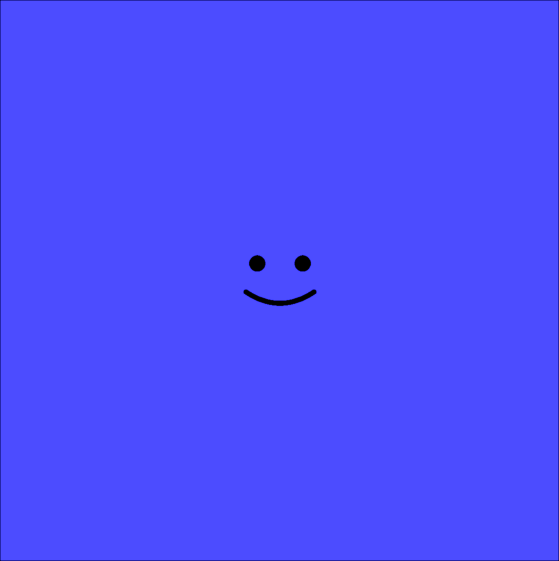

In [20]:
convert_png_to_exr(
    RayTracing.jmfp("/Users/johnmyslinski/Documents/PBRJ/ref/smile3.png"),
    RayTracing.jmfp("/Users/johnmyslinski/Documents/PBRJ/ref/smile3_post.exr"),
)